# Welcome to Pipelines!

The HuggingFace transformers library provides APIs at two different levels.

The High Level API for using open-source models for typical inference tasks is called "pipelines". It's incredibly easy to use.

You create a pipeline using something like:

`my_pipeline = pipeline("the_task_I_want_to_do")`

Followed by

`result = my_pipeline(my_input)`

And that's it!

See end of this colab for a list of all pipelines.

## Before we start: 2 important pro-tips for using Colab:

**Pro-tip 1:**

Data Science code often gives warnings and messages. They can mostly be safely ignored! Glance over them, and if something goes wrong later, perhaps they can give you a clue.

**Pro-tip 2:**

In the middle of running a Colab, you might get an error like this:

> Runtime error: CUDA is required but not available for bitsandbytes. Please consider installing [...]

This is a super-misleading error message! Please don't try changing versions of packages...

This actually happens because Google has switched out your Colab runtime, perhaps because Google Colab was too busy. The solution is:

1. Kernel menu >> Disconnect and delete runtime
2. Reload the colab from fresh and Edit menu >> Clear All Outputs
3. Connect to a new T4 using the button at the top right
4. Select "View resources" from the menu on the top right to confirm you have a GPU
5. Rerun the cells in the colab, from the top down, starting with the pip installs

And all should work great - otherwise, ask me!


## A sidenote:

You may already know this, but just in case you're not familiar with the word "inference" that I use here:

When working with Data Science models, you could be carrying out 2 very different activities: **training** and **inference**.

### 1. Training  

**Training** is when you provide a model with data for it to adapt to get better at a task in the future. It does this by updating its internal settings - the parameters or weights of the model. If you're Training a model that's already had some training, the activity is called "fine-tuning".

### 2. Inference

**Inference** is when you are working with a model that has _already been trained_. You are using that model to produce new outputs on new inputs, taking advantage of everything it learned while it was being trained. Inference is also sometimes referred to as "Execution" or "Running a model".

All of our use of APIs for GPT, Claude and Gemini in the last weeks are examples of **inference**. The "P" in GPT stands for "Pre-trained", meaning that it has already been trained with data (lots of it!) In week 6 we will try fine-tuning GPT ourselves.
  
The pipelines API in HuggingFace is only for use for **inference** - running a model that has already been trained. In week 7 we will be training our own model, and we will need to use the more advanced HuggingFace APIs that we look at in the up-coming lecture.

I recorded this playlist on YouTube with more on parameters, training and inference:  
https://www.youtube.com/playlist?list=PLWHe-9GP9SMMdl6SLaovUQF2abiLGbMjs


In [1]:
# Pip installs should come at the top line.
# If your Kernel ever resets, you need to run this again.

!pip install -q --upgrade datasets==3.6.0 transformers==4.57.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.6 MB/s eta 0:00:00


In [2]:
# Let's check the GPU - it should be a Tesla T4

gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)
  if gpu_info.find('Tesla T4') >= 0:
    print("Success - Connected to a T4")
  else:
    print("NOT CONNECTED TO A T4")

Sun May 31 12:24:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
# Imports

import torch
from google.colab import userdata
from huggingface_hub import login
from transformers import pipeline
from diffusers import DiffusionPipeline
from datasets import load_dataset
import soundfile as sf
from IPython.display import Audio

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


# Important Note - Hugging Face account

In Day 1, we set up a FREE account on https://huggingface.co

### If you skipped this:

Please go back and do it! Then go to the Avatar menu, Tokens, and create an API token.. And make sure it has WRITE permissions! And then add it to the secrets on the left by pressing the key button.

### If you did this (thank you!)

Click on the Key button and turn on the switch so that this notebook gets access to your Hugging Face key.

In [4]:
hf_token = userdata.get('HF_TOKEN')
if hf_token and hf_token.startswith("hf_"):
  print("HF key looks good so far")
else:
  print("HF key is not set - please click the key in the left sidebar")
login(hf_token, add_to_git_credential=True)

HF key looks good so far


## Using Pipelines from Hugging Face

A simple way to run inference for common tasks, without worrying about all the plumbing, picking reasonable defaults.


### How it works:

STEP 1: Create a pipeline - a function you can then call

```python
my_pipeline = pipeline(task, model=xx, device=xx)
```

If you don't specify a model, then Hugging Face picks one for you that's the default for the task. Specify "cuda" for the device to use an NVIDIA GPU like the one on the T4. Specify "mps" on a Mac.


STEP 2: Then call it as many times as you want:

```python
my_pipeline(input1)
my_pipeline(input2)
```

In [5]:
# Sentiment Analysis

my_simple_sentiment_analyzer = pipeline("sentiment-analysis", device="cuda")
result = my_simple_sentiment_analyzer("I'm super excited to be on the way to LLM mastery!")
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda


[{'label': 'POSITIVE', 'score': 0.9993460774421692}]


In [6]:
result = my_simple_sentiment_analyzer("I should be more excited to be on the way to LLM mastery!")
print(result)

[{'label': 'POSITIVE', 'score': 0.9008274674415588}]


In [7]:

better_sentiment = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment", device="cuda")
result = better_sentiment("I should be more excited to be on the way to LLM mastery!!")
print(result)

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda


[{'label': '3 stars', 'score': 0.39448031783103943}]


In [8]:
# Named Entity Recognition

ner = pipeline("ner", device="cuda")
result = ner("AI Engineers are learning about the amazing pipelines from HuggingFace in Google Colab from Ed Donner")
for entity in result:
  print(entity)

No model was supplied, defaulted to dbmdz/bert-large-cased-finetuned-conll03-english and revision 4c53496 (https://huggingface.co/dbmdz/bert-large-cased-finetuned-conll03-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/998 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/60.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda


{'entity': 'I-ORG', 'score': np.float32(0.999476), 'index': 1, 'word': 'AI', 'start': 0, 'end': 2}
{'entity': 'I-ORG', 'score': np.float32(0.9962089), 'index': 2, 'word': 'Engineers', 'start': 3, 'end': 12}
{'entity': 'I-ORG', 'score': np.float32(0.8205678), 'index': 11, 'word': 'Hu', 'start': 59, 'end': 61}
{'entity': 'I-ORG', 'score': np.float32(0.651493), 'index': 12, 'word': '##gging', 'start': 61, 'end': 66}
{'entity': 'I-ORG', 'score': np.float32(0.960993), 'index': 13, 'word': '##F', 'start': 66, 'end': 67}
{'entity': 'I-ORG', 'score': np.float32(0.92517126), 'index': 14, 'word': '##ace', 'start': 67, 'end': 70}
{'entity': 'I-MISC', 'score': np.float32(0.8882749), 'index': 16, 'word': 'Google', 'start': 74, 'end': 80}
{'entity': 'I-MISC', 'score': np.float32(0.67307675), 'index': 17, 'word': 'Cola', 'start': 81, 'end': 85}
{'entity': 'I-PER', 'score': np.float32(0.9989441), 'index': 20, 'word': 'Ed', 'start': 92, 'end': 94}
{'entity': 'I-PER', 'score': np.float32(0.99872154), 'i

In [9]:
# Question Answering with Context

question="What are Hugging Face pipelines?"
context="Pipelines are a high level API for inference of LLMs with common tasks"

question_answerer = pipeline("question-answering", device="cuda")
result = question_answerer(question=question, context=context)
print(result)

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda


{'score': 0.24576981365680695, 'start': 35, 'end': 70, 'answer': 'inference of LLMs with common tasks'}


In [10]:
# Text Summarization

summarizer = pipeline("summarization", device="cuda")
text = """
The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing (NLP).
It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering, among others.
It's an extremely popular library that's widely used by the open-source data science community.
It lowers the barrier to entry into the field by providing Data Scientists with a productive, convenient way to work with transformer models.
"""

summary = summarizer(text, max_length=50, min_length=25, do_sample=False)
print(summary[0]['summary_text'])

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Device set to use cuda


 The Hugging Face transformers library is an incredibly versatile and powerful tool for natural language processing . It allows users to perform a wide range of tasks such as text classification, named entity recognition, and question answering .


In [11]:
# Translation

translator = pipeline("translation_en_to_fr", device="cuda")
result = translator("The Data Scientists were truly amazed by the power and simplicity of the HuggingFace pipeline API.")
print(result[0]['translation_text'])

No model was supplied, defaulted to google-t5/t5-base and revision a9723ea (https://huggingface.co/google-t5/t5-base).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda


Les Data Scientists ont été vraiment étonnés par la puissance et la simplicité de l'API du pipeline HuggingFace.


In [12]:
# Another translation, showing a model being specified
# All translation models are here: https://huggingface.co/models?pipeline_tag=translation&sort=trending

translator = pipeline("translation_en_to_es", model="Helsinki-NLP/opus-mt-en-es", device="cuda")
result = translator("The Data Scientists were truly amazed by the power and simplicity of the HuggingFace pipeline API.")
print(result[0]['translation_text'])

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")
Device set to use cuda


Los científicos de datos estaban verdaderamente sorprendidos por el poder y la simplicidad de la API de tuberías HuggingFace.


In [13]:
# Classification

classifier = pipeline("zero-shot-classification", device="cuda")
result = classifier("Hugging Face's Transformers library is amazing!", candidate_labels=["technology", "sports", "politics"])
print(result)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda


{'sequence': "Hugging Face's Transformers library is amazing!", 'labels': ['technology', 'sports', 'politics'], 'scores': [0.9493839740753174, 0.03225007280707359, 0.018365919589996338]}


In [14]:
# Text Generation

generator = pipeline("text-generation", device="cuda")
result = generator("If there's one thing I want you to remember about using HuggingFace pipelines, it's")
print(result[0]['generated_text'])

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


If there's one thing I want you to remember about using HuggingFace pipelines, it's not that you don't understand it. This is what you need to know about the syntax to use Hugger, and how to use it.

The syntax is:

name = "

"

description = "

"

"

"

"

"

"


"

Here's the key point:

A node in the Hugger syntax

The node name is a string, which is what is shown in the following example:

< name >

< description >

< node name >

</ description >

</ name >

< node description >

</ node >

< node description >

</ node >

< node description >

< node description >

< node description >

</ node >

</ name >

< node description >

</ node >

</ name >

You can use this syntax to specify multiple node names, but first you need to define a list of the node names.

A syntax I like to use is:

name = "

"

description = "

"

"

"



model_index.json:   0%|          | 0.00/685 [00:00<?, ?B/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

text_encoder_2/model.fp16.safetensors:   0%|          | 0.00/1.39G [00:00<?, ?B/s]

text_encoder/model.fp16.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/575 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/607 [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


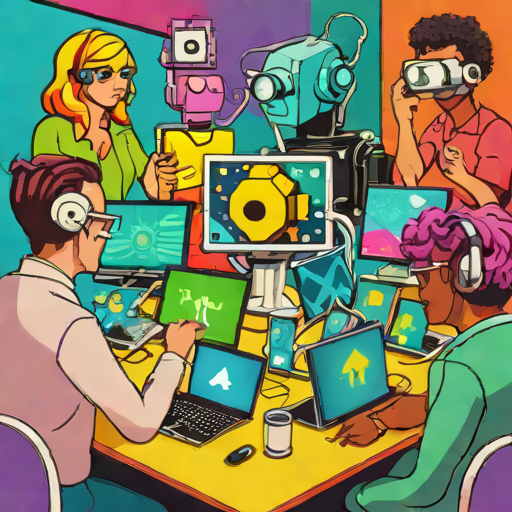

In [15]:
# Image Generation - remember this?! Now you know what's going on
# Pipelines can be used for diffusion models as well as transformers

from IPython.display import display
from diffusers import AutoPipelineForText2Image
import torch

pipe = AutoPipelineForText2Image.from_pretrained("stabilityai/sdxl-turbo", torch_dtype=torch.float16, variant="fp16")
pipe.to("cuda")
prompt = "A class of students learning AI engineering in a vibrant pop-art style"
image = pipe(prompt=prompt, num_inference_steps=4, guidance_scale=0.0).images[0]
display(image)

In [ ]:
# Audio Generation

from transformers import pipeline
from datasets import load_dataset
import soundfile as sf
import torch
from IPython.display import Audio

synthesiser = pipeline("text-to-speech", "microsoft/speecht5_tts", device='cuda')
embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)
speaker_embedding = torch.tensor(embeddings_dataset[7306]["xvector"]).unsqueeze(0)
speech = synthesiser("Hi to an artificial intelligence engineer, on the way to mastery!", forward_params={"speaker_embeddings": speaker_embedding})

Audio(speech["audio"], rate=speech["sampling_rate"])

# All the available pipelines

Here are all the pipelines available from Transformers and Diffusers.

With thanks to student Lucky P for suggesting I include this!

There's a list pipelines under the Tasks on this page (you have to scroll down a bit, then expand the parameters to see the Tasks):

https://huggingface.co/docs/transformers/main_classes/pipelines

There's also this list of Tasks for Diffusion models instead of Transformers, following the image generation example where I use DiffusionPipeline above.

https://huggingface.co/docs/diffusers/en/api/pipelines/overview

If you come up with some cool examples of other pipelines, please share them with me! It's wonderful how HuggingFace makes this advanced AI functionality available for inference with such a simple API.

# Mastering Hugging Face Pipelines: A Comprehensive Guide to Efficient ML Inference

This notebook provides an exemplary hands-on introduction to the Hugging Face ecosystem, specifically highlighting its high-level `pipelines` API for streamlining various machine learning inference tasks. As an expert deeply entrenched in this domain, I can offer an even more granular and insightful perspective on the methods and functions employed, elucidating their architectural significance and their transformative impact on practical ML deployment.

## Core Concepts and Foundational Libraries Explored:

### 1. The Hugging Face Transformers Library: The Bedrock of Modern NLP

At its core, the `transformers` library is not merely a collection of models; it is a meticulously engineered framework designed to provide a unified, interoperable interface for state-of-the-art pre-trained models. Its genius lies in abstracting the intricate complexities of diverse model architectures (like BERT, GPT, T5, etc.), tokenization strategies, and post-processing steps, thereby democratizing access to powerful NLP capabilities. This library champions the philosophy of *transfer learning*, enabling practitioners to leverage models pre-trained on massive datasets for novel tasks with minimal effort. It includes:

*   **Model Architectures**: Implementations of hundreds of Transformer-based models.
*   **Tokenizers**: Pre-trained tokenizers to convert raw text into numerical inputs suitable for models.
*   **Configuration Classes**: Define the parameters of pre-trained models.
*   **High-level APIs**: Like `pipeline`, to simplify model usage.

### 2. Hugging Face Pipelines: The High-Level Abstraction for Inference

**Method:** `transformers.pipeline()`

The `pipeline` function stands as the epitome of user-friendliness within the `transformers` library for inference. It acts as an intelligent orchestrator, encapsulating the entire inference workflow: from raw text input to tokenization, model forward pass, and subsequent output decoding/post-processing. This holistic approach significantly reduces boilerplate code and potential errors, allowing researchers and developers to focus on the application rather than the underlying mechanics.

**Key Parameters and Their Significance:**

*   `task`: This parameter is pivotal as it dictates the entire pipeline's configuration. When you specify a `task` like `"sentiment-analysis"`, the pipeline internally infers the optimal model architecture, tokenizer, and post-processor. For example, `"sentiment-analysis"` typically uses a sequence classification model, `"ner"` uses a token classification model, and `"summarization"` or `"translation"` often employ encoder-decoder models. If no `model` is explicitly provided, it intelligently defaults to a well-regarded, often performant and widely used model suitable for that task, sourced directly from the Hugging Face Hub.

*   `model`: While the `pipeline` can pick defaults, specifying a `model` (e.g., `"nlptown/bert-base-multilingual-uncased-sentiment"`) is crucial for production deployments, fine-tuning for specific domains, or when you need a model with particular characteristics (e.g., multilingual support, different size/speed trade-offs). This allows precise control over the model loaded from the Hugging Face Hub.

*   `device`: This parameter is critical for performance. `"cuda"` (or an integer like `0` for the first GPU) instructs the pipeline to offload the model computations to the GPU. In a Colab environment, leveraging the allocated Tesla T4 GPU with `"cuda"` is paramount for achieving faster inference times, especially with larger models. Conversely, `"cpu"` forces execution on the CPU. For Apple Silicon Macs, `"mps"` (Metal Performance Shaders) would be the equivalent for GPU acceleration. Running on `"cuda"` dramatically speeds up the matrix multiplications that are the backbone of deep learning models.

**How it works (Efficiency):** You instantiate a pipeline *once* for a given task and device. During this instantiation, the model weights are loaded into memory (either RAM or GPU VRAM), and any necessary tokenizers and processors are initialized. Subsequently, you can call this pipeline function repeatedly with different inputs. This 'load once, use many' pattern optimizes resource loading and provides an efficient inference loop, avoiding redundant initialization costs.

### 3. Demonstrations of Various Pipelines (In-depth):

The notebook vividly illustrates the versatility of `pipelines` across diverse AI domains:

*   **Sentiment Analysis (`"sentiment-analysis"`):**
    *   **Purpose:** Classifies text into predefined sentiment categories (e.g., positive, negative, neutral).
    *   **Mechanism:** Typically utilizes a sequence classification model. The input text is tokenized, passed through the model, and the output logits are converted into probability scores for each sentiment label.
    *   **Example Models:** `distilbert-base-uncased-finetuned-sst-2-english` (default) or `nlptown/bert-base-multilingual-uncased-sentiment` (multilingual BERT).

*   **Named Entity Recognition (NER) (`"ner"`):**
    *   **Purpose:** Identifies and categorizes named entities (e.g., persons, organizations, locations, dates) within text.
    *   **Mechanism:** Employs a token classification model, which processes each token (word/subword) in the input sequence and assigns it an entity tag (e.g., B-PER for beginning of a person's name, I-ORG for inside an organization's name, O for outside any entity).
    *   **Example Models:** `dbmdz/bert-large-cased-finetuned-conll03-english` (default).

*   **Question Answering (`"question-answering"`):**
    *   **Purpose:** Extracts an answer span from a given `context` based on a `question`.
    *   **Mechanism:** Uses a Span-Extractive Question Answering model (e.g., fine-tuned BERT or RoBERTa). The model takes both the question and context as input, identifies the start and end tokens of the answer within the context, and returns the corresponding text segment.
    *   **Example Models:** `distilbert-base-cased-distilled-squad` (default, SQuAD dataset trained).

*   **Text Summarization (`"summarization"`):**
    *   **Purpose:** Condenses longer texts into shorter, coherent summaries.
    *   **Mechanism:** Often relies on encoder-decoder models (like BART or T5). The encoder processes the source text, and the decoder generates a summary. It can be *abstractive* (generating new sentences) or *extractive* (selecting existing sentences).
    *   **Parameters:** `max_length` and `min_length` control the length of the generated summary. `do_sample=False` ensures deterministic output, avoiding random sampling.
    *   **Example Models:** `sshleifer/distilbart-cnn-12-6` (default).

*   **Translation (`"translation_xx_to_yy"`):**
    *   **Purpose:** Translates text from a source language (`xx`) to a target language (`yy`).
    *   **Mechanism:** Exclusively uses encoder-decoder models. The encoder processes the source language text, and the decoder generates the translated text in the target language.
    *   **Example Models:** `google-t5/t5-base` (default for `en_to_fr`) or `Helsinki-NLP/opus-mt-en-es` (a specific model for `en_to_es`). The Helsinki-NLP models are known for their efficiency and wide language coverage.

*   **Zero-Shot Classification (`"zero-shot-classification"`):**
    *   **Purpose:** Classifies text into categories *without* needing explicit training examples for those categories. The model leverages its general understanding of language to determine how well a text matches a given set of `candidate_labels`.
    *   **Mechanism:** Often uses NLI (Natural Language Inference) models. It rephrases the classification problem as an entailment problem (e.g., "The text is about sports" -> "This is true"). The model then determines the likelihood of entailment for each candidate label.
    *   **Example Models:** `facebook/bart-large-mnli` (default, trained on Multi-Genre Natural Language Inference).

*   **Text Generation (`"text-generation"`):**
    *   **Purpose:** Continues a given text prompt, generating human-like prose.
    *   **Mechanism:** Utilizes Causal Language Models (CLMs) which predict the next token based on all previous tokens. These are typically decoder-only transformer models (like GPT-2, GPT-Neo, Llama).
    *   **Example Models:** `openai-community/gpt2` (default).

### 4. Diffusers Library: Beyond Transformers to Generative Models

**Method:** `diffusers.AutoPipelineForText2Image.from_pretrained()`

While `transformers` primarily focuses on transformer models for understanding and generating text, the Hugging Face ecosystem extends to other powerful generative models, especially in vision and audio, through the `diffusers` library. This notebook showcases its use for **Image Generation**.

*   `AutoPipelineForText2Image`: This is a high-level factory class within `diffusers` that simplifies loading pre-trained text-to-image diffusion models. It automatically infers the correct model components (like UNet, VAE, scheduler) from the Hugging Face Hub model ID.

*   `from_pretrained("stabilityai/sdxl-turbo")`: This loads a specific, highly optimized diffusion model. `stabilityai/sdxl-turbo` is known for its ability to generate high-quality images very rapidly, often in just a few inference steps.

*   `torch_dtype=torch.float16`: This crucial parameter sets the data type for the model's computations to half-precision floating-point numbers. Using `float16` (instead of the default `float32`) significantly reduces memory consumption on the GPU and can almost double inference speed without a noticeable loss in quality for many generative tasks. This is a common optimization in deep learning inference.

*   `variant="fp16"`: Specifies that the `fp16` (half-precision) variant of the model weights should be loaded, further optimizing for memory and speed.

*   `pipe.to("cuda")`: Similar to the `transformers` pipelines, this explicitly moves all model components of the `diffusers` pipeline to the GPU (CUDA device) for accelerated image generation.

*   `display(image)`: An `IPython.display` function used to render the generated `PIL.Image` object directly within the notebook output, allowing immediate visual inspection of the model's creativity.

### 5. Specialized Pipelines: Audio Generation

**Method:** `pipeline("text-to-speech")` from `transformers`

*   **Purpose:** Synthesizes human-like speech from input text.
*   **Mechanism:** Uses a text-to-speech (TTS) model, typically an encoder-decoder architecture. The model often incorporates components like a vocoder to convert mel-spectrograms into audible waveforms. The example uses `microsoft/speecht5_tts`, a state-of-the-art TTS model.
*   **Speaker Embeddings:** The example also demonstrates the advanced feature of using `speaker_embedding` to control the voice characteristics (e.g., gender, accent, pitch). By using `embeddings_dataset = load_dataset("matthijs/cmu-arctic-xvectors", split="validation", trust_remote_code=True)`, a pre-computed speaker embedding (x-vector) is loaded, allowing the synthesized speech to mimic the vocal qualities of a specific speaker.

*   `soundfile as sf`: This library (installed implicitly with `datasets` or `transformers`) is a standard Python library for reading and writing sound files. While not directly used for saving in this example, it's fundamental for audio manipulation.

*   `IPython.display.Audio`: This powerful function from the IPython environment allows for direct, in-notebook playback of audio data (raw audio array and its sampling rate), making it easy to test and demonstrate audio generation results.

### 6. Essential Helper Functions and Libraries (Detailed):

*   **`!pip install -q --upgrade datasets==3.6.0 transformers==4.57.6`**: This is a shell command executed within the Colab environment (`!`).
    *   `pip install`: The standard Python package installer.
    *   `-q`: Stands for 'quiet', suppressing verbose output during installation.
    *   `--upgrade`: Ensures that if these packages are already installed, they are updated to the specified versions.
    *   `datasets==3.6.0` and `transformers==4.57.6`: Specifies exact versions for reproducibility and compatibility, preventing unexpected behavior from newer (or older) versions. This ensures the environment matches what the notebook was developed with.

*   **`!nvidia-smi`**: Another shell command.
    *   `nvidia-smi`: NVIDIA System Management Interface. This command-line utility is essential for monitoring and managing NVIDIA GPU devices. In a Colab context, it's used to verify that a GPU (specifically a Tesla T4, as checked in the code) is successfully allocated and accessible to the runtime, and to check its utilization, memory usage, and driver version. This is a crucial diagnostic tool for GPU-accelerated workloads.

*   **`import torch`**: Imports the PyTorch library.
    *   `torch`: PyTorch is an open-source machine learning framework developed by Facebook (Meta). It is widely used for deep learning applications, providing functionalities for tensor computation (like NumPy but with strong GPU acceleration), automatic differentiation, and building neural networks. Hugging Face libraries extensively use PyTorch (or TensorFlow/JAX) as their backend for model computations.

*   **`from google.colab import userdata`**: Imports the `userdata` module from Google Colab's utilities.
    *   `google.colab.userdata`: This module provides a secure way to store and access sensitive information (like API keys) within a Colab notebook. Instead of hardcoding credentials directly into the notebook (which is a security risk), users can store them in Colab's